In [21]:
import pandas as pd
import numpy as np
import seaborn as sns

data = {
    "Date": [
        "2024-01-05", "2024-01-12", "2024-01-19", "2024-01-26",
        "2024-02-02", "2024-02-09", "2024-02-16", "2024-02-23",
        "2024-03-01", "2024-03-08"
    ],
    "Temperature_c": [12.5, 14, 11, 15.5, 17, 13, 18.5, 16, 20, 9.5],
    "Humidity-%": [72, 68, 80, 65, 60, 75, 58, 62, 55, 88],
    "Wind-KMph": [6, 8.5, 4, 10, 12, 5.5, 14, 9, 15.5, 2],
    "Rainfall_mm": [0, 0, 2.5, 0, 0, 5, 0, 1.2, 0, 0],
    "Pm2.5": [145, 128, 168, 112, 95, 140, 88, 105, 76, 310]
}

df = pd.DataFrame(data)
print(df)

         Date  Temperature_c  Humidity-%  Wind-KMph  Rainfall_mm  Pm2.5
0  2024-01-05           12.5          72        6.0          0.0    145
1  2024-01-12           14.0          68        8.5          0.0    128
2  2024-01-19           11.0          80        4.0          2.5    168
3  2024-01-26           15.5          65       10.0          0.0    112
4  2024-02-02           17.0          60       12.0          0.0     95
5  2024-02-09           13.0          75        5.5          5.0    140
6  2024-02-16           18.5          58       14.0          0.0     88
7  2024-02-23           16.0          62        9.0          1.2    105
8  2024-03-01           20.0          55       15.5          0.0     76
9  2024-03-08            9.5          88        2.0          0.0    310


In [44]:
df["Date"] = pd.to_datetime(df["Date"])
print(df.dtypes)

Date             datetime64[us]
Temperature_c           float64
Humidity-%                int64
Wind-KMph               float64
Rainfall_mm             float64
Pm2.5                     int64
dtype: object


In [45]:
print(df.shape)

(10, 6)


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           10 non-null     datetime64[us]
 1   Temperature_c  10 non-null     float64       
 2   Humidity-%     10 non-null     int64         
 3   Wind-KMph      10 non-null     float64       
 4   Rainfall_mm    10 non-null     float64       
 5   Pm2.5          10 non-null     int64         
dtypes: datetime64[us](1), float64(3), int64(2)
memory usage: 612.0 bytes


In [47]:
df.describe()

,Date,Temperature_c,Humidity-%,Wind-KMph,Rainfall_mm,Pm2.5
count,10,10.000000,10.00000,10.000000,10.000000,10.000000
mean,2024-02-05 12:00:00,14.700000,68.30000,8.650000,0.870000,136.700000
min,2024-01-05 00:00:00,9.500000,55.00000,2.000000,0.000000,76.000000
25%,2024-01-20 18:00:00,12.625000,60.50000,5.625000,0.000000,97.500000
50%,2024-02-05 12:00:00,14.750000,66.50000,8.750000,0.000000,120.000000
75%,2024-02-21 06:00:00,16.750000,74.25000,11.500000,0.900000,143.750000
max,2024-03-08 00:00:00,20.000000,88.00000,15.500000,5.000000,310.000000
std,NaN,3.318299,10.46741,4.365585,1.670695,67.146689


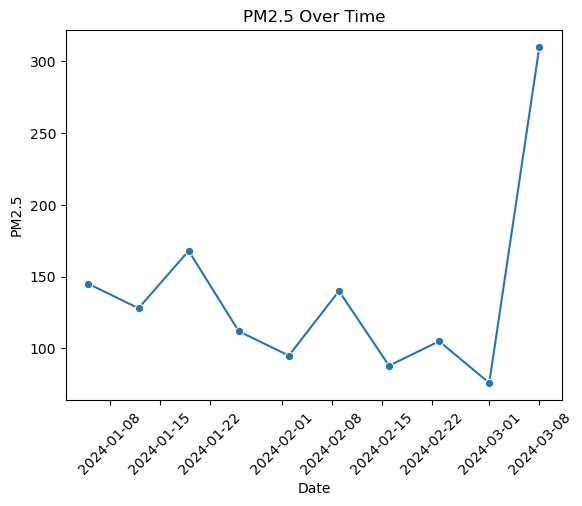

In [48]:
import matplotlib.pyplot as plt

sns.lineplot(data=df, x="Date", y="Pm2.5", marker="o")

plt.title("PM2.5 Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)

plt.show()

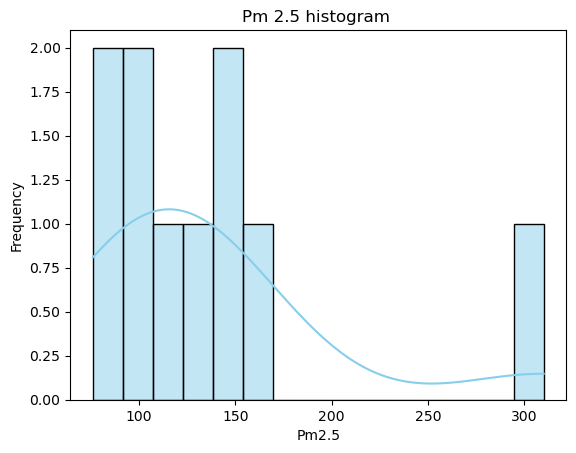

In [49]:
plt.figure()
sns.histplot(data=df, x="Pm2.5", bins=15, kde=True, color="skyblue")
plt.title("Pm 2.5 histogram ")
plt.xlabel("Pm2.5")
plt.ylabel("Frequency")
plt.show()

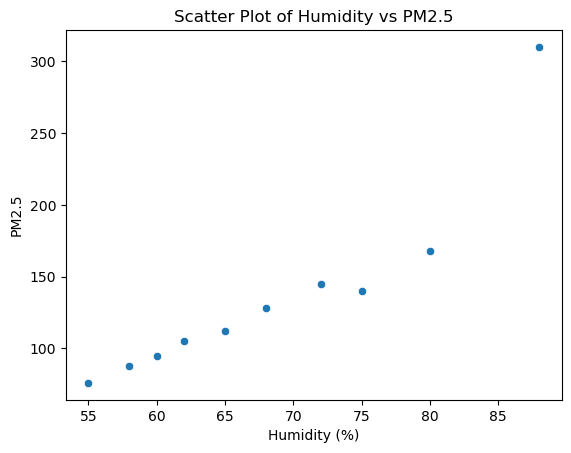

In [50]:
sns.scatterplot(data=df, x="Humidity-%", y="Pm2.5")

plt.title("Scatter Plot of Humidity vs PM2.5")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5")

plt.show()

Q1 = 97.5
Q3 = 143.75
IQR = 46.25
Lower Fence = 28.125
Upper Fence = 213.125

Outliers:
        Date  Temperature_c  Humidity-%  Wind-KMph  Rainfall_mm  Pm2.5
9 2024-03-08            9.5          88        2.0          0.0    310


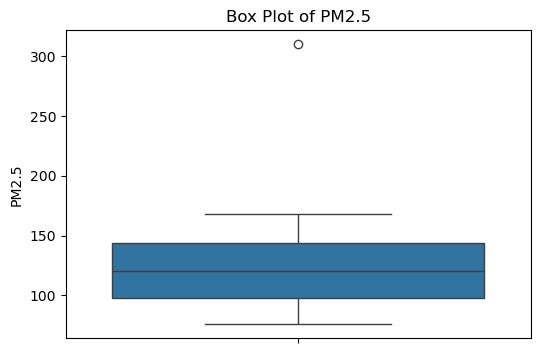

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

Q1 = df["Pm2.5"].quantile(0.25)
Q3 = df["Pm2.5"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Fence =", lower_fence)
print("Upper Fence =", upper_fence)

outliers = df[(df["Pm2.5"] < lower_fence) | (df["Pm2.5"] > upper_fence)]

print("\nOutliers:")
print(outliers)

plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Pm2.5"])

plt.title("Box Plot of PM2.5")
plt.ylabel("PM2.5")

plt.show()

Slope = -17.13824419778002
Intercept = 388.63218970736625
R-squared = 0.7173227417131307


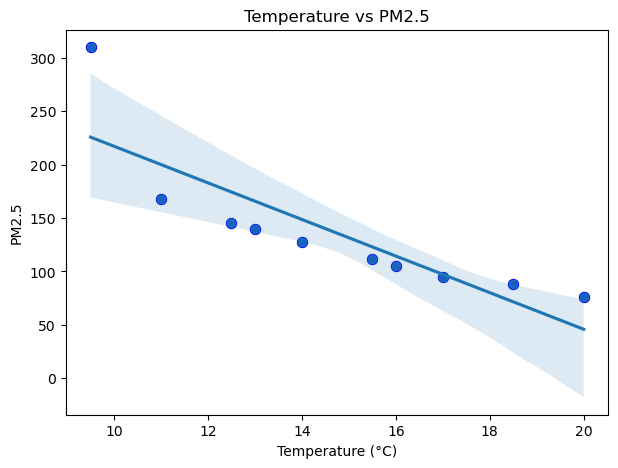

In [52]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["Temperature_c"]]
y = df["Pm2.5"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

print("Slope =", slope)
print("Intercept =", intercept)
print("R-squared =", r2)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Temperature_c", y="Pm2.5", color="blue", s=80)

sns.regplot(data=df, x="Temperature_c", y="Pm2.5")

plt.title("Temperature vs PM2.5")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5")
plt.show()